In [11]:
%pip install scikit-learn

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 991.0 kB/s eta 0:00:09
   - -------------------------------------- 0.2/8.3 MB 2.9 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/8.3 MB 6.5 MB/s eta 0:00:02
   -------- ------------------------------- 1.7/8.3 MB 9.8 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.3 MB 11.9 MB/s eta 0:00:01
   --------------- ------------------------ 3.2/8.3 MB 12.6 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 12.5 MB/s eta 0:00:01
   -------------------- ------------------- 4.3/8.3 MB 12.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 12.7 MB/s eta 0:00:01
   ------------------------------ ---


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [6]:
image_path = "../output_videos/cropped_image.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

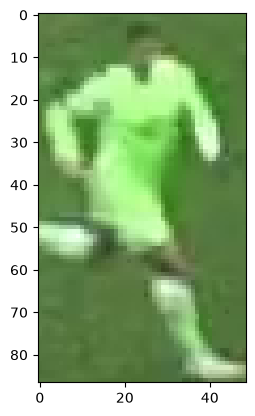

In [7]:
plt.imshow(image)
plt.show()

# take the top half of the image

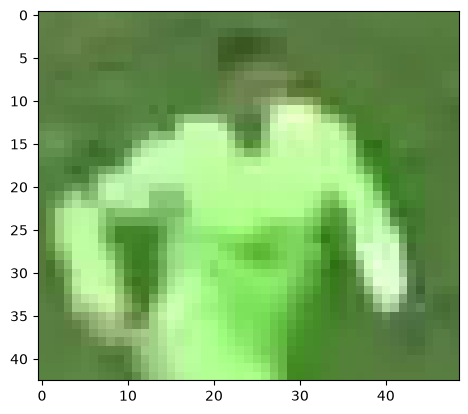

In [8]:
top_half_image=  image[0: int(image.shape[0]/2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into two clusters

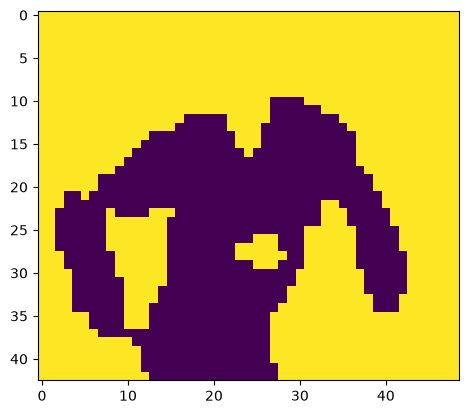

In [13]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into the orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clustered image
plt.imshow(clustered_image)
plt.show()

In [14]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [15]:

player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [16]:

kmeans.cluster_centers_[player_cluster]

array([171.16802168, 236.00677507, 142.90108401])